# California Housing Price Prediction with XGBoost

This project applies XGBoost regression to predict median house values using the California Housing dataset. A linear regression model is used as a baseline, followed by experiments that examine how the number of trees and learning rate affect predictive performance.

## 1. Dataset Overview

The California Housing dataset contains information about housing districts in California, including median income, house age, average rooms, population, occupancy, and geographic location.

The target variable, `MedHouseVal`, represents the median house value for each district.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

df.head()

Dataset shape: (20640, 9)
Missing values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

Training samples: 16,512
Test samples: 4,128


## 2. Baseline and XGBoost Modeling

A linear regression model is used as a baseline to establish a reference level of predictive performance. XGBoost is then trained on the same data split to capture nonlinear relationships and feature interactions.

Both models are evaluated using Mean Absolute Error (MAE) and Mean Squared Error (MSE) on the training and test sets.

In [3]:
# Train a linear regression baseline.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

# Train XGBoost with an initial set of hyperparameters.
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate both models on the training and test sets.
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "Train MAE": [
        mean_absolute_error(y_train, linear_train_pred),
        mean_absolute_error(y_train, xgb_train_pred)
    ],
    "Test MAE": [
        mean_absolute_error(y_test, linear_test_pred),
        mean_absolute_error(y_test, xgb_test_pred)
    ],
    "Train MSE": [
        mean_squared_error(y_train, linear_train_pred),
        mean_squared_error(y_train, xgb_train_pred)
    ],
    "Test MSE": [
        mean_squared_error(y_test, linear_test_pred),
        mean_squared_error(y_test, xgb_test_pred)
    ]
})

results.round(4)

,Model,Train MAE,Test MAE,Train MSE,Test MSE
0,Linear Regression,0.5286,0.5332,0.5179,0.5559
1,XGBoost,0.2922,0.3251,0.1782,0.2380


XGBoost substantially outperforms the linear regression baseline on the test set. Test MSE decreases from **0.5559 to 0.2380**, a reduction of approximately **57%**, while test MAE decreases from **0.5332 to 0.3251**.

The improvement suggests that nonlinear relationships and feature interactions play an important role in predicting housing values and are better captured by the tree-based ensemble model.

## 3. Hyperparameter Analysis

XGBoost performance depends strongly on the configuration of the boosting process. Two key hyperparameters are examined:

- **Number of trees (`n_estimators`)** — controls the number of boosting iterations.
- **Learning rate (`learning_rate`)** — controls the contribution of each new tree to the ensemble.

Each parameter is varied independently while the remaining model settings are held fixed. Training and test MSE are compared to evaluate both predictive performance and generalization.

### Effect of the Number of Trees

The number of boosting trees is varied from 50 to 800 while keeping the tree depth and learning rate fixed. This experiment examines whether additional boosting iterations continue to improve predictive performance.

In [4]:
tree_values = [50, 100, 200, 400, 800]

train_mse_trees = []
test_mse_trees = []

# Train XGBoost models with increasing ensemble sizes.
for n_trees in tree_values:
    model = XGBRegressor(
        n_estimators=n_trees,
        max_depth=4,
        learning_rate=0.1,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse_trees.append(mean_squared_error(y_train, train_pred))
    test_mse_trees.append(mean_squared_error(y_test, test_pred))

tree_results = pd.DataFrame({
    "Number of Trees": tree_values,
    "Train MSE": train_mse_trees,
    "Test MSE": test_mse_trees
})

tree_results.round(4)

,Number of Trees,Train MSE,Test MSE
0,50,0.2663,0.3009
1,100,0.2178,0.2628
2,200,0.1782,0.2380
3,400,0.1406,0.2212
4,800,0.1021,0.2088


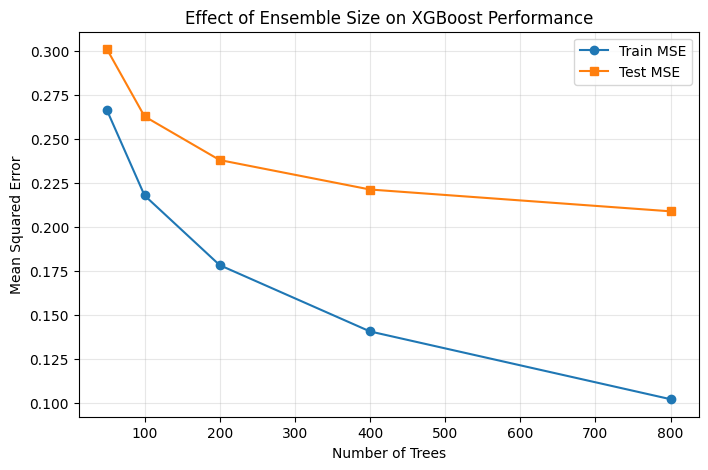

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(tree_values, train_mse_trees, marker="o", label="Train MSE")
plt.plot(tree_values, test_mse_trees, marker="s", label="Test MSE")

plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Ensemble Size on XGBoost Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As the ensemble grows from 50 to 800 trees, test MSE decreases from **0.3009 to 0.2088**, while training MSE decreases continuously.

The largest improvements occur at lower tree counts, with progressively smaller gains as more trees are added. No increase in test error is observed within the tested range, although the widening train–test gap suggests that additional complexity increasingly improves training fit relative to generalization.

### Effect of the Learning Rate

The learning rate is varied while keeping the ensemble size fixed at 200 trees. This experiment evaluates how the magnitude of each boosting update affects convergence and predictive performance.

In [6]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]

train_mse_lr = []
test_mse_lr = []

# Train models with different learning rates using a fixed ensemble size.
for rate in learning_rates:
    model = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=rate,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse_lr.append(mean_squared_error(y_train, train_pred))
    test_mse_lr.append(mean_squared_error(y_test, test_pred))

learning_rate_results = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Train MSE": train_mse_lr,
    "Test MSE": test_mse_lr
})

learning_rate_results.round(4)

,Learning Rate,Train MSE,Test MSE
0,0.001,1.0749,1.0615
1,0.010,0.4016,0.4290
2,0.050,0.2188,0.2611
3,0.100,0.1782,0.2380
4,0.300,0.1175,0.2112


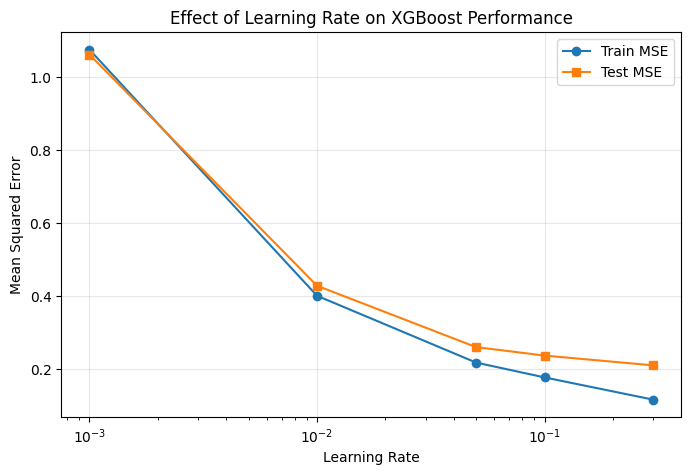

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(learning_rates, train_mse_lr, marker="o", label="Train MSE")
plt.plot(learning_rates, test_mse_lr, marker="s", label="Test MSE")

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Learning Rate on XGBoost Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

With the ensemble size fixed at 200 trees, increasing the learning rate substantially improves model performance across the tested range. Test MSE decreases from **1.0615 at 0.001** to **0.2112 at 0.3**.

The largest improvement occurs between the smaller learning rates, while performance gains become more gradual at higher values. Among the tested settings, a learning rate of **0.3 achieves the lowest test MSE**.

However, this trend should not be interpreted as larger learning rates always producing better performance. Excessively large updates can reduce model stability and generalization, so the learning rate should be tuned together with other boosting parameters.